# SQLite gaming revenue analysis

This notebook **reads** `data/gaming.sqlite` and walks through the retained official gaming data.
It does **not** download, parse, or write to the database.

- `gaming_results` holds operator or statewide observations we kept from collectors.
- `source_coverage` describes what each collector found (ok, partial, blocked, etc.).
- One logical period can have multiple `source_sha256` values when a regulator revises a report.
- Revenue definitions differ by state: GGR, AGR, taxable revenue, and net proceeds are **not** interchangeable.

In [1]:
from pathlib import Path
import sqlite3
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from variant_gaming.common import project_root
from variant_gaming.consolidate import (
    build_operator_revenue,
    build_state_period_revenue,
    dedupe_latest_observation,
)
from variant_gaming.storage import default_db_path

ROOT = project_root()
database_path = default_db_path(ROOT)
connection = sqlite3.connect(
    f"file:{database_path.as_posix()}?mode=ro",
    uri=True,
)
database_path, database_path.stat().st_size

(WindowsPath('C:/Users/Sean/VscProjects/researchOS/data/gaming.sqlite'),
 13893632)

In [2]:
coverage = pd.read_sql_query("SELECT * FROM source_coverage", connection)
results = pd.read_sql_query("SELECT * FROM gaming_results", connection)

print(f"gaming_results rows: {len(results):,}")
print(f"states with rows: {results['state_code'].nunique()}")

rows_by_state_vertical = (
    results.groupby(["state_code", "vertical"], dropna=False)
    .size()
    .rename("row_count")
    .reset_index()
    .sort_values(["state_code", "vertical"])
)
display(rows_by_state_vertical)

period_span = (
    results.groupby(["state_code", "vertical"], dropna=False)
    .agg(earliest_period=("period_start", "min"), latest_period=("period_end", "max"))
    .reset_index()
    .sort_values(["state_code", "vertical"])
)
display(period_span)

non_ok_coverage = coverage.loc[coverage["status"] != "ok", ["state_code", "vertical", "status", "reason"]].copy()
display(non_ok_coverage.sort_values(["status", "state_code"]))

gaming_results rows: 18,394
states with rows: 19


,state_code,vertical,row_count
0,CT,online_casino,223
1,CT,online_sports_betting,174
2,DC,online_sports_betting,62
3,DE,online_casino,612
4,IA,online_sports_betting,1669
5,IL,online_sports_betting,891
6,IN,online_sports_betting,1025
7,LA,online_sports_betting,55
8,MA,online_sports_betting,291
9,MD,online_sports_betting,351


,state_code,vertical,earliest_period,latest_period
0,CT,online_casino,2021-10-01,2026-07-31
1,CT,online_sports_betting,2021-10-01,2026-07-31
2,DC,online_sports_betting,2024-07-01,2026-07-31
3,DE,online_casino,2013-11-01,2026-07-31
4,IA,online_sports_betting,2019-08-01,2026-07-31
5,IL,online_sports_betting,2020-03-01,2026-06-30
6,IN,online_sports_betting,2019-10-01,2026-07-31
7,LA,online_sports_betting,2021-07-01,2026-07-31
8,MA,online_sports_betting,2023-03-01,2026-07-31
9,MD,online_sports_betting,2024-08-01,2026-07-31


,state_code,vertical,status,reason
33,OR,online_sports_betting,annual_only,Official public reporting is mainly annual/sum...
16,AZ,online_sports_betting,blocked,Official reports landing blocked for automated...
34,DE,online_sports_betting,blocked,Official tables split casino sportsbooks vs Sp...
19,KY,online_sports_betting,blocked,Current sports wagering market report is Table...
27,WY,online_sports_betting,blocked_or_unavailable_export,Combined wagering activity landing returned no...
29,AR,online_sports_betting,combined_only,Official public landing does not expose an iso...
30,NV,online_sports_betting,combined_only,Official GRI monthly PDFs provide sports-pool ...
21,ME,online_casino,legal_not_reporting,"I-Gaming authorized in law, but no official op..."
32,MT,location_based_mobile_sports_betting,location_based_mobile,Montana sports wagers are tied to sales-agent ...
28,FL,online_sports_betting,not_publicly_available,No official monthly online sportsbook series o...


## Build current analytical views

We reuse `variant_gaming.consolidate` instead of inventing new rules in the notebook.

1. **Amendments must be deduplicated.** Official PDFs and Excel files get revised. `gaming_results` keeps every hash, but charts should use one latest observation per business key (`dedupe_latest_observation`).
2. **Do not blindly sum revenue across bases.** GGR, AGR, taxable revenue, and net proceeds measure different legal concepts.
3. **Keep `revenue_basis` on every chart and table.** The label prevents treating Massachusetts taxable gaming revenue as if it were another state's GGR.

In [3]:
latest_results = dedupe_latest_observation(results)
state_period = build_state_period_revenue(results)
operator_revenue = build_operator_revenue(results)

print(f"raw rows: {len(results):,} | after latest-observation dedupe: {len(latest_results):,}")
print(f"state-period rows: {len(state_period):,} | operator rows: {len(operator_revenue):,}")
display(state_period["revenue_basis"].value_counts(dropna=False).rename("periods"))

raw rows: 18,394 | after latest-observation dedupe: 18,392
state-period rows: 2,270 | operator rows: 16,567


revenue_basis
GGR                1386
taxable_revenue     475
net_proceeds        292
AGR                  76
NaN                  41
Name: periods, dtype: int64

In [4]:
latest_idx = state_period.groupby(["state_code", "vertical"])["period_start"].idxmax()
latest_overview = (
    state_period.loc[latest_idx]
    .loc[:, [
        "state_code",
        "vertical",
        "period_start",
        "handle",
        "revenue",
        "revenue_basis",
        "operator_count",
        "aggregation_source",
    ]]
    .rename(columns={"period_start": "latest_month", "revenue": "reported_revenue"})
    .sort_values(["state_code", "vertical"])
    .reset_index(drop=True)
)
latest_overview

,state_code,vertical,latest_month,handle,reported_revenue,revenue_basis,operator_count,aggregation_source
0,CT,online_casino,2026-07-01,1.865517e+09,5.556381e+07,GGR,4,operator_sum
1,CT,online_sports_betting,2026-07-01,1.756544e+08,1.266224e+07,GGR,3,operator_sum
2,DC,online_sports_betting,2026-07-01,2.412010e+07,2.314579e+06,GGR,2,operator_sum
3,DE,online_casino,2026-07-01,3.584446e+08,1.343825e+07,net_proceeds,3,official_statewide_total
4,IA,online_sports_betting,2026-07-01,1.731755e+08,1.678639e+07,net_proceeds,19,official_statewide_total
5,IL,online_sports_betting,2026-06-01,1.121596e+09,8.941282e+07,AGR,16,official_statewide_total
6,IN,online_sports_betting,2026-07-01,3.776077e+08,4.080943e+07,GGR,11,official_statewide_total
7,LA,online_sports_betting,2026-07-01,2.692667e+08,3.331711e+07,net_proceeds,0,official_statewide_total
8,MA,online_sports_betting,2026-07-01,5.871019e+08,6.510199e+07,taxable_revenue,7,operator_sum
9,MD,online_sports_betting,2026-07-01,4.891599e+08,4.195000e+07,taxable_revenue,15,official_statewide_total


## Massachusetts online sportsbook walkthrough

Massachusetts reports **Taxable Gaming Revenue**, not GGR. Charts and tables below keep that label.

In [5]:
ma_operators = operator_revenue.loc[
    (operator_revenue["state_code"] == "MA")
    & (operator_revenue["vertical"] == "online_sports_betting")
].copy()

ma_monthly = (
    ma_operators.groupby("period_start", as_index=False)
    .agg(
        handle=("handle", "sum"),
        taxable_revenue=("taxable_revenue", "sum"),
        tax=("tax", "sum"),
        operator_count=("operator", "nunique"),
    )
)
ma_monthly["taxable_revenue_hold_pct"] = (
    100.0 * ma_monthly["taxable_revenue"] / ma_monthly["handle"]
)
ma_monthly = ma_monthly.sort_values("period_start").reset_index(drop=True)

display(ma_monthly.head(3))
display(ma_monthly.tail(3))

,period_start,handle,taxable_revenue,tax,operator_count,taxable_revenue_hold_pct
0,2023-03-01,5.481025e+08,45605606.68,9121121.34,6,8.320635
1,2023-04-01,5.662369e+08,58548295.26,11709653.81,6,10.339895
2,2023-05-01,4.435597e+08,59410840.40,11882168.06,8,13.394102


,period_start,handle,taxable_revenue,tax,operator_count,taxable_revenue_hold_pct
38,2026-05-01,6.249865e+08,70070108.76,14014021.76,7,11.211460
39,2026-06-01,6.089041e+08,53623096.13,10724619.23,7,8.806493
40,2026-07-01,5.871019e+08,65101989.55,13020397.81,7,11.088704


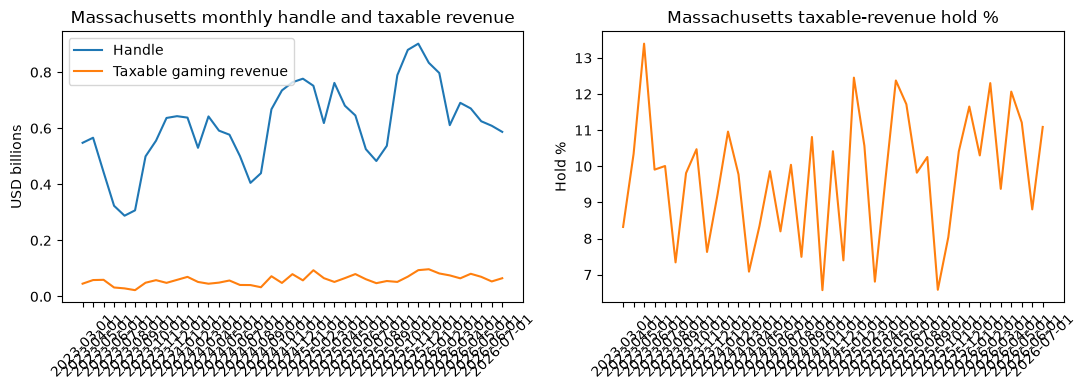

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(ma_monthly["period_start"], ma_monthly["handle"] / 1e9, label="Handle")
axes[0].plot(
    ma_monthly["period_start"],
    ma_monthly["taxable_revenue"] / 1e9,
    label="Taxable gaming revenue",
)
axes[0].set_title("Massachusetts monthly handle and taxable revenue")
axes[0].set_ylabel("USD billions")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend()

axes[1].plot(ma_monthly["period_start"], ma_monthly["taxable_revenue_hold_pct"], color="tab:orange")
axes[1].set_title("Massachusetts taxable-revenue hold %")
axes[1].set_ylabel("Hold %")
axes[1].tick_params(axis="x", rotation=45)

fig.tight_layout()
plt.show()

Latest Massachusetts reporting month: 2026-07-01


,operator,handle,taxable_revenue,handle_share_pct,taxable_revenue_share_pct
0,DraftKings,2.811763e+08,32324402.68,47.892254,49.651943
1,FanDuel,1.505948e+08,16801318.96,25.650547,25.807689
2,Fanatics,5.968206e+07,6453759.09,10.165537,9.913305
3,BetMGM,5.279115e+07,6386566.27,8.991820,9.810094
4,theScore Bet,2.198188e+07,1622011.39,3.744134,2.491493
5,Caesars Sportsbook,1.760358e+07,1129965.58,2.998386,1.735685
6,Bally Bet,3.272046e+06,383965.58,0.557322,0.589791


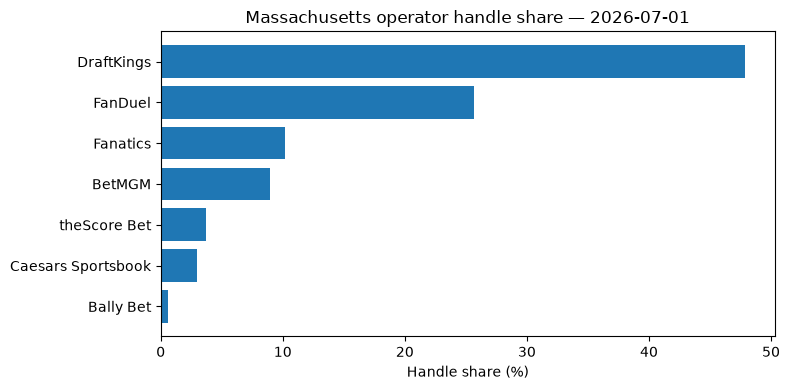

In [7]:
latest_ma_month = ma_monthly["period_start"].iloc[-1]
print(f"Latest Massachusetts reporting month: {latest_ma_month}")

ma_latest_ops = ma_operators.loc[ma_operators["period_start"] == latest_ma_month].copy()
handle_total = ma_latest_ops["handle"].sum()
taxable_total = ma_latest_ops["taxable_revenue"].sum()

ma_shares = ma_latest_ops.loc[:, ["operator", "handle", "taxable_revenue"]].copy()
ma_shares["handle_share_pct"] = 100.0 * ma_shares["handle"] / handle_total
ma_shares["taxable_revenue_share_pct"] = 100.0 * ma_shares["taxable_revenue"] / taxable_total
ma_shares = ma_shares.sort_values("handle_share_pct", ascending=False).reset_index(drop=True)
display(ma_shares)

fig, ax = plt.subplots(figsize=(8, 4))
plot_frame = ma_shares.sort_values("handle_share_pct")
ax.barh(plot_frame["operator"], plot_frame["handle_share_pct"])
ax.set_xlabel("Handle share (%)")
ax.set_title(f"Massachusetts operator handle share — {latest_ma_month}")
fig.tight_layout()
plt.show()

connection.close()

## Basic observations

This notebook shows how to inventory SQLite coverage, build latest analytical views with the existing consolidate helpers, and inspect Massachusetts taxable-revenue trends and operator shares.

**Revenue-basis limitation.** States do not all report the same metric. Comparing a GGR state with Massachusetts taxable gaming revenue without labels would misstate the market.

**Reporting-lag limitation.** The newest calendar month is often not yet published. Treat "latest month" as the latest *available* official month, not today.

**What to do next.** Choose the next analytical question (for example seasonality, multi-state hold comparison, or operator continuity) before promoting more plotting helpers into modules. Analysis should drive the code, not the other way around.